<a href="https://colab.research.google.com/github/BahruzHuseynov/AI_Projects/blob/main/Bird_Recognition_with_EfficientNet_Scratch_40.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# To ignore possible warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import torch
import torch.nn as nn
from math import ceil

base_model = [
    # expand_ratio, channels, repeats, stride, kernel_size
    [1, 16, 1, 1, 3],
    [6, 24, 2, 2, 3],
    [6, 40, 2, 2, 5],
    [6, 80, 3, 2, 3],
    [6, 112, 3, 1, 5],
    [6, 192, 4, 2, 5],
    [6, 320, 1, 1, 3],
]

phi_values = {
    # tuple of: (phi_value, resolution, drop_rate)
    "b0": (0, 224, 0.2),  # alpha, beta, gamma, depth = alpha ** phi
    "b1": (0.5, 240, 0.2),
    "b2": (1, 260, 0.3),
    "b3": (2, 300, 0.3),
    "b4": (3, 380, 0.4),
    "b5": (4, 456, 0.4),
    "b6": (5, 528, 0.5),
    "b7": (6, 600, 0.5),
}


class CNNBlock(nn.Module):
    def __init__(
        self, in_channels, out_channels, kernel_size, stride, padding, groups=1
    ):
        super(CNNBlock, self).__init__()
        self.cnn = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size,
            stride,
            padding,
            groups=groups,
            bias=False,
        )
        self.bn = nn.BatchNorm2d(out_channels)
        self.silu = nn.SiLU()  # SiLU <-> Swish

    def forward(self, x):
        return self.silu(self.bn(self.cnn(x)))


class SqueezeExcitation(nn.Module):
    def __init__(self, in_channels, reduced_dim):
        super(SqueezeExcitation, self).__init__()
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),  # C x H x W -> C x 1 x 1
            nn.Conv2d(in_channels, reduced_dim, 1),
            nn.SiLU(),
            nn.Conv2d(reduced_dim, in_channels, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return x * self.se(x)


class InvertedResidualBlock(nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels,
        kernel_size,
        stride,
        padding,
        expand_ratio,
        reduction=4,  # squeeze excitation
        survival_prob=0.8,  # for stochastic depth
    ):
        super(InvertedResidualBlock, self).__init__()
        self.survival_prob = 0.8
        self.use_residual = in_channels == out_channels and stride == 1
        hidden_dim = in_channels * expand_ratio
        self.expand = in_channels != hidden_dim
        reduced_dim = int(in_channels / reduction)

        if self.expand:
            self.expand_conv = CNNBlock(
                in_channels,
                hidden_dim,
                kernel_size=3,
                stride=1,
                padding=1,
            )

        self.conv = nn.Sequential(
            CNNBlock(
                hidden_dim,
                hidden_dim,
                kernel_size,
                stride,
                padding,
                groups=hidden_dim,
            ),
            SqueezeExcitation(hidden_dim, reduced_dim),
            nn.Conv2d(hidden_dim, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
        )

    def stochastic_depth(self, x):
        if not self.training:
            return x

        binary_tensor = (
            torch.rand(x.shape[0], 1, 1, 1, device=x.device) < self.survival_prob
        )
        return torch.div(x, self.survival_prob) * binary_tensor

    def forward(self, inputs):
        x = self.expand_conv(inputs) if self.expand else inputs

        if self.use_residual:
            return self.stochastic_depth(self.conv(x)) + inputs
        else:
            return self.conv(x)


class EfficientNet(nn.Module):
    def __init__(self, version, num_classes):
        super(EfficientNet, self).__init__()
        width_factor, depth_factor, dropout_rate = self.calculate_factors(version)
        last_channels = ceil(1280 * width_factor)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.features = self.create_features(width_factor, depth_factor, last_channels)
        self.classifier = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(last_channels, num_classes),
        )

    def calculate_factors(self, version, alpha=1.2, beta=1.1):
        phi, res, drop_rate = phi_values[version]
        depth_factor = alpha**phi
        width_factor = beta**phi
        return width_factor, depth_factor, drop_rate

    def create_features(self, width_factor, depth_factor, last_channels):
        channels = int(32 * width_factor)
        features = [CNNBlock(3, channels, 3, stride=2, padding=1)]
        in_channels = channels

        for expand_ratio, channels, repeats, stride, kernel_size in base_model:
            out_channels = 4 * ceil(int(channels * width_factor) / 4)
            layers_repeats = ceil(repeats * depth_factor)

            for layer in range(layers_repeats):
                features.append(
                    InvertedResidualBlock(
                        in_channels,
                        out_channels,
                        expand_ratio=expand_ratio,
                        stride=stride if layer == 0 else 1,
                        kernel_size=kernel_size,
                        padding=kernel_size // 2,  # if k=1:pad=0, k=3:pad=1, k=5:pad=2
                    )
                )
                in_channels = out_channels

        features.append(
            CNNBlock(in_channels, last_channels, kernel_size=1, stride=1, padding=0)
        )

        return nn.Sequential(*features)

    def forward(self, x):
        x = self.pool(self.features(x))
        return self.classifier(x.view(x.shape[0], -1))


def test():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    version = "b0"
    phi, res, drop_rate = phi_values[version]
    num_examples, num_classes = 4, 10
    x = torch.randn((num_examples, 3, res, res)).to(device)
    model = EfficientNet(
        version=version,
        num_classes=num_classes,
    ).to(device)

    print(model(x).shape)  # (num_examples, num_classes)


if __name__ == "__main__":
    test()

In [2]:
# Importing all necessary libraries used in the code
import numpy as np  
import pandas as pd
from PIL import Image  

import torch
import torch.nn as nn
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
import torchvision.transforms as transforms
import torch.optim as optim

# About the dataset
<p style = "text-align: justify;">
Generally, the dataset contains 200 various bird species with 50-60 images per class and total number of images is 11.8k. The shape of each image differs from each other significantly, for example, 3x300x500, 3x337x400, 3x400x500 and so on. 
</p>

# About the model. 
<p style = "text-align: justify;">
In this notebook, I have built the model from scratch.
</p>

# EfficientNet-B0 from scratch

In [3]:
class SqueezeExcitation(nn.Module):
    def __init__(self, in_channels, reduction_ratio = 4): 
        super(SqueezeExcitation, self).__init__()
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_channels, in_channels // reduction_ratio, kernel_size=1),
            nn.ReLU(),
            nn.Conv2d(in_channels // reduction_ratio, in_channels, kernel_size=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return x * self.se(x)

In [4]:
class MBConvBlock(nn.Module):
    def __init__(self, in_channels, 
                 out_channels, 
                 expand_ratio, 
                 kernel_size, 
                 stride, 
                 reduction_ratio=4, 
                 dropout_rate=0.2):
        super(MBConvBlock, self).__init__()

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.expansion_factor = expand_ratio
        self.kernel_size = kernel_size
        self.stride = stride
        self.reduction_ratio = reduction_ratio
        self.dropout_rate = dropout_rate

        expanded_channels = expand_ratio * in_channels
        if self.expansion_factor != 1:
            self.expansion_sequence = nn.Sequential(
                nn.Conv2d(in_channels, expanded_channels, kernel_size=1, stride=1, padding=0, bias=False),
                nn.BatchNorm2d(expanded_channels),
                nn.SiLU(),
            )
        
        self.dw_conv = nn.Conv2d(expanded_channels, expanded_channels, 
                                 kernel_size=kernel_size, 
                                 stride=stride, padding=(kernel_size - 1) // 2, 
                                 groups=expanded_channels, bias=False)
        self.dw_bn = nn.BatchNorm2d(expanded_channels)
        self.dw_swish = nn.SiLU()
        if self.reduction_ratio is not None:
            self.SE = SqueezeExcitation(expanded_channels, reduction_ratio)
        self.conv2 = nn.Conv2d(expanded_channels, out_channels, kernel_size=1, stride=1, padding=0, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        out = x
        if self.expansion_factor != 1:
            out = self.expansion_sequence(x)

        out = self.dw_conv(out)
        out = self.dw_bn(out)
        out = self.dw_swish(out)
        if self.reduction_ratio is not None:
            out = self.SE(out)
        out = self.conv2(out)
        out = self.bn2(out)

        # Skip connection
        if self.stride == 1 and out.shape[1] == x.shape[1]:
            out += x

        
        drop = nn.Dropout(0.2)
        out = drop(out)
        return out

In [5]:
class EfficientNetB0(nn.Module):
    def __init__(self, num_classes):
        super(EfficientNetB0, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(32)
        self.swish1 = nn.SiLU()
        self.blocks = nn.Sequential(
                MBConvBlock(32, 16, kernel_size=3, stride=1, expand_ratio=1),
                MBConvBlock(16, 24, kernel_size=3, stride=2, expand_ratio=6),
                MBConvBlock(24, 24, kernel_size=3, stride=1, expand_ratio=6),
                MBConvBlock(24, 40, kernel_size=5, stride=2, expand_ratio=6),
                MBConvBlock(40, 40, kernel_size=5, stride=1, expand_ratio=6),
                MBConvBlock(40, 80, kernel_size=3, stride=2, expand_ratio=6),
                MBConvBlock(80, 80, kernel_size=3, stride=1, expand_ratio=6),
                MBConvBlock(80, 80, kernel_size=3, stride=1, expand_ratio=6),
                MBConvBlock(80, 112, kernel_size=5, stride=1, expand_ratio=6),
                MBConvBlock(112, 112, kernel_size=5, stride=1, expand_ratio=6),
                MBConvBlock(112, 112, kernel_size=5, stride=1, expand_ratio=6),
                MBConvBlock(112, 192, kernel_size=5, stride=2, expand_ratio=6),
                MBConvBlock(192, 192, kernel_size=5, stride=1, expand_ratio=6),
                MBConvBlock(192, 192, kernel_size=5, stride=1, expand_ratio=6),
                MBConvBlock(192, 192, kernel_size=5, stride=1, expand_ratio=6),
                MBConvBlock(192, 320, kernel_size=3, stride=1, expand_ratio=6),
            )
        

        self.rest = nn.Sequential(
            nn.Conv2d(320, 1280, kernel_size=1, stride=1, bias=False),
            nn.BatchNorm2d(1280),
            nn.SiLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Dropout(0.2),
        ) 

        self.fc = nn.Linear(1280, num_classes)

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.swish1(out)
        out = self.blocks(out)
        out = self.rest(out)
        
        out = out.view(out.size(0), -1)
        out = self.fc(out)
        return out

In [ ]:
c = EfficientNetB0(200)
c.train()  # Look at the architecture

EfficientNetB0(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (swish1): SiLU()
  (blocks): Sequential(
    (0): MBConvBlock(
      (dw_conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
      (dw_bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (dw_swish): SiLU()
      (SE): SqueezeExcitation(
        (se): Sequential(
          (0): AdaptiveAvgPool2d(output_size=1)
          (1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
          (2): SiLU()
          (3): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
          (4): Sigmoid()
        )
      )
      (conv2): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): MBConvBlock(
      (expansion_seq

# Model 1.
#### Making a dataset from the directory in Google Drive. In this dataset, there are only 20 images per each class and center crop has been applied on all of them. Dataset has been standardized here.

In [ ]:
data_dir = "./drive/MyDrive/created_dataset"

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor()
])

dataset = ImageFolder(root=data_dir, transform=transform)

In [ ]:
# Mean: tensor([0.4819, 0.4887, 0.4194]), Standard Deviation: tensor([0.0459, 0.0451, 0.0483])
mean = torch.tensor([0.4819, 0.4887, 0.4194])
std = torch.tensor([0.0459, 0.0451, 0.0483])

In [ ]:
# Define a new transform with normalization
new_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

dataset_normalized = ImageFolder(root=data_dir, transform=new_transform)

#### Stratified data splitting (training, validation and test)

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit

def train_test_validation(dataset, targets):
    stratified_split = StratifiedShuffleSplit(n_splits=1, train_size=0.8, test_size=0.2)

    for train_indices, indices in stratified_split.split(dataset, targets):
        train_dataset = torch.utils.data.Subset(dataset, train_indices)
        
        dct_val = {}
        dct_test = {}
        val_indices = []
        test_indices = []

        for i in indices:
            x = targets[i]

            if x not in dct_val.keys():
                dct_val[x] = 1
                val_indices.append(i)
            elif x in dct_val.keys() and dct_val[x] == 1:
                dct_val[x] += 1
                val_indices.append(i)
            else:
                test_indices.append(i)
                if x in dct_test.keys():
                    dct_test[x] += 1
                else:
                    dct_test[x] = 1

        test_dataset = torch.utils.data.Subset(dataset, test_indices)
        val_dataset = torch.utils.data.Subset(dataset, val_indices)
    return train_dataset, test_dataset, val_dataset

In [ ]:
train_dataset, test_dataset, val_dataset = train_test_validation(dataset_normalized, dataset_normalized.targets)

In [ ]:
print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")
print(f"Entire dataset size: {len(dataset_normalized)}")

Train dataset size: 3200
Validation dataset size: 400
Test dataset size: 400
Entire dataset size: 4000


In [ ]:
batch_size = 8
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

#### Model, optimizer and loss

In [ ]:
model = EfficientNetB0(200)

optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

#### Training (Training duration of Model 1: 3 hours 35 minutes 57 seconds)
#### Validation has not been used

In [ ]:
epochs = 8

for epoch in range(epochs):
    train_loss = 0
    train_acc = 0
    model.train()
    for images, labels in train_loader:
        optimizer.zero_grad()
        output = model(images)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * images.size(0)
        _, preds = torch.max(output, 1)
        train_acc += torch.sum(preds == labels.data)
    
    train_loss = train_loss / len(train_loader.dataset)
    train_acc = train_acc / len(train_loader.dataset)
    print(f'Epoch {epoch+1}/{epochs} | Train loss: {train_loss:.4f} | Train accuracy: {train_acc:.4f}')

Epoch 1/8 | Train loss: 5.3401 | Train accuracy: 0.0072
Epoch 2/8 | Train loss: 5.1408 | Train accuracy: 0.0078
Epoch 3/8 | Train loss: 5.0184 | Train accuracy: 0.0141
Epoch 4/8 | Train loss: 4.9504 | Train accuracy: 0.0128
Epoch 5/8 | Train loss: 4.8389 | Train accuracy: 0.0234
Epoch 6/8 | Train loss: 4.7263 | Train accuracy: 0.0297
Epoch 7/8 | Train loss: 4.6431 | Train accuracy: 0.0334
Epoch 8/8 | Train loss: 4.5154 | Train accuracy: 0.0413


# Model 2.
#### This time, all images with original shape will be used; however, Resize(300,300) will be applied which makes changes on resolution and in some cases use cropping. The number of images per class won't change.

In [ ]:
data_dir = "./drive/MyDrive/created_dataset2"

transform = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.ToTensor(),
])

dataset = ImageFolder(root=data_dir, transform=transform)

In [ ]:
train_dataset, test_dataset, val_dataset = train_test_validation(dataset, dataset.targets)

In [ ]:
print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")
print(f"Entire dataset size: {len(dataset)}")

Train dataset size: 3200
Validation dataset size: 400
Test dataset size: 400
Entire dataset size: 4000


In [ ]:
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

#### Moreover, now the device module will be assigned to GPU.

In [ ]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("There is a GPU available.")
else:
    device = torch.device("cpu")
    print("There is no GPU available, using CPU instead.")

There is a GPU available.


#### Model, optimizer and loss (this time SGD with momentum will be used)

In [ ]:
model = EfficientNetB0(200)
model.to(device)

optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9)
criterion = nn.CrossEntropyLoss()

#### Training - (Training duration of Model 2: )
#### Validation will be used after each epoch
#### After each 5 epoch, the learning rate will be decreased 10 times.

In [ ]:
from torch.optim.lr_scheduler import StepLR

num_epochs = 20
scheduler = StepLR(optimizer, step_size = 5, gamma = 0.1)

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    running_corrects = 0
     
    for batch, labels in train_loader:
        batch, labels = batch.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(batch)
        _, preds = torch.max(outputs, 1)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        running_corrects += torch.sum(preds == labels.data)

    scheduler.step()
    
    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = running_corrects.double() / len(train_dataset)
    print(f'Epoch {epoch+1}/{num_epochs} | Train loss: {epoch_loss:.4f} | Train accuracy: {epoch_acc:.4f}')
    
    # Validation
    model.eval()
    running_val_loss = 0.0
    running_val_corrects = 0
    
    for batch, labels in val_loader:
        with torch.no_grad():
            batch, labels = batch.to(device), labels.to(device)

            outputs = model(batch)
            val_loss = criterion(outputs, labels)
            running_val_loss += val_loss.item()
            _, val_preds = torch.max(outputs, 1)
            running_val_corrects += torch.sum(val_preds == labels.data)
    
    val_loss = running_val_loss / len(val_dataset)
    val_acc = running_val_corrects.double() / len(val_dataset)
    print(f'Epoch {epoch+1}/{num_epochs} | Validation loss: {val_loss:.4f} | Validation accuracy: {val_acc:.4f}')

Epoch 1/20 | Train loss: 0.1674 | Train accuracy: 0.0063
Epoch 1/20 | Validation loss: 0.1667 | Validation accuracy: 0.0075
Epoch 2/20 | Train loss: 0.1593 | Train accuracy: 0.0078
Epoch 2/20 | Validation loss: 0.1687 | Validation accuracy: 0.0075
Epoch 3/20 | Train loss: 0.1553 | Train accuracy: 0.0141
Epoch 3/20 | Validation loss: 0.1616 | Validation accuracy: 0.0100
Epoch 4/20 | Train loss: 0.1514 | Train accuracy: 0.0187
Epoch 4/20 | Validation loss: 0.1587 | Validation accuracy: 0.0375
Epoch 5/20 | Train loss: 0.1490 | Train accuracy: 0.0184
Epoch 5/20 | Validation loss: 0.1565 | Validation accuracy: 0.0350
Epoch 6/20 | Train loss: 0.1430 | Train accuracy: 0.0381
Epoch 6/20 | Validation loss: 0.1489 | Validation accuracy: 0.0525
Epoch 7/20 | Train loss: 0.1408 | Train accuracy: 0.0387
Epoch 7/20 | Validation loss: 0.1481 | Validation accuracy: 0.0525
Epoch 8/20 | Train loss: 0.1389 | Train accuracy: 0.0441
Epoch 8/20 | Validation loss: 0.1469 | Validation accuracy: 0.0575
Epoch 9/

# Model 3.

#### Moreover, now the device module will be assigned to GPU.

In [6]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("There is a GPU available.")
else:
    device = torch.device("cpu")
    print("There is no GPU available, using CPU instead.")

There is a GPU available.


In [7]:
data_dir = "./drive/MyDrive/images"

transform = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.ToTensor(),
])

dataset = ImageFolder(root=data_dir, transform=transform)

In [8]:
from sklearn.model_selection import StratifiedShuffleSplit

def train_test_validation2(dataset, targets):
    stratified_split = StratifiedShuffleSplit(n_splits=1, train_size=0.8, test_size=0.2)

    for train_indices, indices in stratified_split.split(dataset, targets):
        train_dataset = torch.utils.data.Subset(dataset, train_indices)
        
        dct = {}
        val_indices = []
        test_indices = []

        for i in indices:
            x = targets[i]

            if x not in dct.keys():
                dct[x] = 1
                test_indices.append(i)
            elif dct[x] % 2 == 0:
                test_indices.append(i)
                dct[x] += 1
            else:
                val_indices.append(i)  
                dct[x] += 1 

        test_dataset = torch.utils.data.Subset(dataset, test_indices)
        val_dataset = torch.utils.data.Subset(dataset, val_indices)

    return train_dataset, test_dataset, val_dataset

In [9]:
train_dataset, test_dataset, val_dataset = train_test_validation2(dataset, dataset.targets)

In [16]:
print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")
print(f"Entire dataset size: {len(dataset)}")

Train dataset size: 9431
Validation dataset size: 1173
Test dataset size: 1185
Entire dataset size: 11789


In [13]:
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

#### Model, optimizer and loss (this time SGD with momentum will be used)

In [12]:
model = EfficientNetB0(200) # batch size 32
model.to(device)

optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9)
criterion = nn.CrossEntropyLoss()

### Training

In [ ]:
from torch.optim.lr_scheduler import StepLR

num_epochs = 20
scheduler = StepLR(optimizer, step_size = 5, gamma = 0.1)

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    running_corrects = 0
     
    for batch, labels in train_loader:
        batch, labels = batch.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(batch)
        _, preds = torch.max(outputs, 1)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        running_corrects += torch.sum(preds == labels.data)

    scheduler.step()
    
    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = running_corrects.double() / len(train_dataset)
    print(f'Epoch {epoch+1}/{num_epochs} | Train loss: {epoch_loss:.4f} | Train accuracy: {epoch_acc:.4f}')
    
    # Validation
    model.eval()
    running_val_loss = 0.0
    running_val_corrects = 0
    
    for batch, labels in val_loader:
        with torch.no_grad():
            batch, labels = batch.to(device), labels.to(device)

            outputs = model(batch)
            val_loss = criterion(outputs, labels)
            running_val_loss += val_loss.item()
            _, val_preds = torch.max(outputs, 1)
            running_val_corrects += torch.sum(val_preds == labels.data)
    
    val_loss = running_val_loss / len(val_dataset)
    val_acc = running_val_corrects.double() / len(val_dataset)
    print(f'Epoch {epoch+1}/{num_epochs} | Validation loss: {val_loss:.4f} | Validation accuracy: {val_acc:.4f}')

Epoch 1/20 | Train loss: 0.1645 | Train accuracy: 0.0074
Epoch 1/20 | Validation loss: 0.1664 | Validation accuracy: 0.0094
Epoch 2/20 | Train loss: 0.1589 | Train accuracy: 0.0094
Epoch 2/20 | Validation loss: 0.1591 | Validation accuracy: 0.0171
Epoch 3/20 | Train loss: 0.1533 | Train accuracy: 0.0224
Epoch 3/20 | Validation loss: 0.1520 | Validation accuracy: 0.0315
Epoch 4/20 | Train loss: 0.1452 | Train accuracy: 0.0333
Epoch 4/20 | Validation loss: 0.1455 | Validation accuracy: 0.0367
Epoch 5/20 | Train loss: 0.1399 | Train accuracy: 0.0408
Epoch 5/20 | Validation loss: 0.1378 | Validation accuracy: 0.0426


KeyboardInterrupt: ignored

### Training 2.

In [ ]:
model = EfficientNetB0(200) # 1 hour 7 minutes
model.to(device) # batch size 32

optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9)
criterion = nn.CrossEntropyLoss()

In [ ]:
from torch.optim.lr_scheduler import StepLR

num_epochs = 20
# scheduler = StepLR(optimizer, step_size = 5, gamma = 0.1)

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    running_corrects = 0
     
    for batch, labels in train_loader:
        batch, labels = batch.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(batch)
        _, preds = torch.max(outputs, 1)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        running_corrects += torch.sum(preds == labels.data)

    # scheduler.step()
    
    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = running_corrects.double() / len(train_dataset)
    print(f'Epoch {epoch+1}/{num_epochs} | Train loss: {epoch_loss:.4f} | Train accuracy: {epoch_acc:.4f}')
    
    # Validation
    model.eval()
    running_val_loss = 0.0
    running_val_corrects = 0
    
    for batch, labels in val_loader:
        with torch.no_grad():
            batch, labels = batch.to(device), labels.to(device)

            outputs = model(batch)
            val_loss = criterion(outputs, labels)
            running_val_loss += val_loss.item()
            _, val_preds = torch.max(outputs, 1)
            running_val_corrects += torch.sum(val_preds == labels.data)
    
    val_loss = running_val_loss / len(val_dataset)
    val_acc = running_val_corrects.double() / len(val_dataset)
    print(f'Epoch {epoch+1}/{num_epochs} | Validation loss: {val_loss:.4f} | Validation accuracy: {val_acc:.4f}')

Epoch 1/20 | Train loss: 0.1589 | Train accuracy: 0.0144
Epoch 1/20 | Validation loss: 0.1631 | Validation accuracy: 0.0179
Epoch 2/20 | Train loss: 0.1458 | Train accuracy: 0.0297
Epoch 2/20 | Validation loss: 0.1459 | Validation accuracy: 0.0315
Epoch 3/20 | Train loss: 0.1389 | Train accuracy: 0.0441
Epoch 3/20 | Validation loss: 0.1413 | Validation accuracy: 0.0648
Epoch 4/20 | Train loss: 0.1338 | Train accuracy: 0.0576
Epoch 4/20 | Validation loss: 0.1372 | Validation accuracy: 0.0622
Epoch 5/20 | Train loss: 0.1303 | Train accuracy: 0.0672
Epoch 5/20 | Validation loss: 0.1326 | Validation accuracy: 0.0716
Epoch 6/20 | Train loss: 0.1263 | Train accuracy: 0.0813
Epoch 6/20 | Validation loss: 0.1263 | Validation accuracy: 0.1108
Epoch 7/20 | Train loss: 0.1220 | Train accuracy: 0.1036
Epoch 7/20 | Validation loss: 0.1252 | Validation accuracy: 0.0997
Epoch 8/20 | Train loss: 0.1189 | Train accuracy: 0.1164
Epoch 8/20 | Validation loss: 0.1203 | Validation accuracy: 0.1151
Epoch 9/

In [14]:
model = EfficientNetB0(200) # batch_size 64
model.to(device) 

optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9)
criterion = nn.CrossEntropyLoss()

In [ ]:
from torch.optim.lr_scheduler import StepLR # 41 minutes 42 seconds

num_epochs = 20
# scheduler = StepLR(optimizer, step_size = 5, gamma = 0.1)

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    running_corrects = 0
     
    for batch, labels in train_loader:
        batch, labels = batch.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(batch)
        _, preds = torch.max(outputs, 1)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        running_corrects += torch.sum(preds == labels.data)

    # scheduler.step()
    
    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = running_corrects.double() / len(train_dataset)
    print(f'Epoch {epoch+1}/{num_epochs} | Train loss: {epoch_loss:.4f} | Train accuracy: {epoch_acc:.4f}')
    
    # Validation
    model.eval()
    running_val_loss = 0.0
    running_val_corrects = 0
    
    for batch, labels in val_loader:
        with torch.no_grad():
            batch, labels = batch.to(device), labels.to(device)

            outputs = model(batch)
            val_loss = criterion(outputs, labels)
            running_val_loss += val_loss.item()
            _, val_preds = torch.max(outputs, 1)
            running_val_corrects += torch.sum(val_preds == labels.data)
    
    val_loss = running_val_loss / len(val_dataset)
    val_acc = running_val_corrects.double() / len(val_dataset)
    print(f'Epoch {epoch+1}/{num_epochs} | Validation loss: {val_loss:.4f} | Validation accuracy: {val_acc:.4f}')

Epoch 1/20 | Train loss: 0.0831 | Train accuracy: 0.0072
Epoch 1/20 | Validation loss: 0.0856 | Validation accuracy: 0.0077
Epoch 2/20 | Train loss: 0.0769 | Train accuracy: 0.0162
Epoch 2/20 | Validation loss: 0.0822 | Validation accuracy: 0.0179
Epoch 3/20 | Train loss: 0.0731 | Train accuracy: 0.0284
Epoch 3/20 | Validation loss: 0.1070 | Validation accuracy: 0.0153
Epoch 4/20 | Train loss: 0.0698 | Train accuracy: 0.0380
Epoch 4/20 | Validation loss: 0.0758 | Validation accuracy: 0.0273
Epoch 5/20 | Train loss: 0.0665 | Train accuracy: 0.0563
Epoch 5/20 | Validation loss: 0.0721 | Validation accuracy: 0.0494
Epoch 6/20 | Train loss: 0.0635 | Train accuracy: 0.0725
Epoch 6/20 | Validation loss: 0.0688 | Validation accuracy: 0.0614
Epoch 7/20 | Train loss: 0.0603 | Train accuracy: 0.1083
Epoch 7/20 | Validation loss: 0.0640 | Validation accuracy: 0.1049
Epoch 8/20 | Train loss: 0.0584 | Train accuracy: 0.1234
Epoch 8/20 | Validation loss: 0.0619 | Validation accuracy: 0.1168
Epoch 9/

Another Model. Batch size 64.

In [18]:
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

In [19]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("There is a GPU available.")
else:
    device = torch.device("cpu")
    print("There is no GPU available, using CPU instead.")

There is a GPU available.


In [20]:
model = EfficientNetB0(200)
model.to(device)

optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9)
criterion = nn.CrossEntropyLoss()

In [21]:
from torch.optim.lr_scheduler import StepLR  # 4 hours 12 minutes

num_epochs = 50
# scheduler = StepLR(optimizer, step_size = 5, gamma = 0.1)

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    running_corrects = 0
     
    for batch, labels in train_loader:
        batch, labels = batch.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(batch)
        _, preds = torch.max(outputs, 1)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        running_corrects += torch.sum(preds == labels.data)

    # scheduler.step()
    
    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = running_corrects.double() / len(train_dataset)
    print(f'Epoch {epoch+1}/{num_epochs} | Train loss: {epoch_loss:.4f} | Train accuracy: {epoch_acc:.4f}')
    
    # Validation
    model.eval()
    running_val_loss = 0.0
    running_val_corrects = 0
    
    for batch, labels in val_loader:
        with torch.no_grad():
            batch, labels = batch.to(device), labels.to(device)

            outputs = model(batch)
            val_loss = criterion(outputs, labels)
            running_val_loss += val_loss.item()
            _, val_preds = torch.max(outputs, 1)
            running_val_corrects += torch.sum(val_preds == labels.data)
    
    val_loss = running_val_loss / len(val_dataset)
    val_acc = running_val_corrects.double() / len(val_dataset)
    print(f'Epoch {epoch+1}/{num_epochs} | Validation loss: {val_loss:.4f} | Validation accuracy: {val_acc:.4f}')

Epoch 1/50 | Train loss: 0.0816 | Train accuracy: 0.0103
Epoch 1/50 | Validation loss: 0.0908 | Validation accuracy: 0.0136
Epoch 2/50 | Train loss: 0.0752 | Train accuracy: 0.0216
Epoch 2/50 | Validation loss: 0.0787 | Validation accuracy: 0.0222
Epoch 3/50 | Train loss: 0.0723 | Train accuracy: 0.0295
Epoch 3/50 | Validation loss: 0.0734 | Validation accuracy: 0.0341
Epoch 4/50 | Train loss: 0.0694 | Train accuracy: 0.0436
Epoch 4/50 | Validation loss: 0.0732 | Validation accuracy: 0.0401
Epoch 5/50 | Train loss: 0.0669 | Train accuracy: 0.0542
Epoch 5/50 | Validation loss: 0.0686 | Validation accuracy: 0.0588
Epoch 6/50 | Train loss: 0.0631 | Train accuracy: 0.0815
Epoch 6/50 | Validation loss: 0.0660 | Validation accuracy: 0.0835
Epoch 7/50 | Train loss: 0.0607 | Train accuracy: 0.0985
Epoch 7/50 | Validation loss: 0.0639 | Validation accuracy: 0.0912
Epoch 8/50 | Train loss: 0.0579 | Train accuracy: 0.1293
Epoch 8/50 | Validation loss: 0.0617 | Validation accuracy: 0.1176
Epoch 9/

In [22]:
from torch.optim.lr_scheduler import StepLR 

num_epochs = 10
# scheduler = StepLR(optimizer, step_size = 5, gamma = 0.1)

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    running_corrects = 0
     
    for batch, labels in train_loader:
        batch, labels = batch.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(batch)
        _, preds = torch.max(outputs, 1)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        running_corrects += torch.sum(preds == labels.data)

    # scheduler.step()
    
    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = running_corrects.double() / len(train_dataset)
    print(f'Epoch {epoch+1}/{num_epochs} | Train loss: {epoch_loss:.4f} | Train accuracy: {epoch_acc:.4f}')
    
    # Validation
    model.eval()
    running_val_loss = 0.0
    running_val_corrects = 0
    
    for batch, labels in val_loader:
        with torch.no_grad():
            batch, labels = batch.to(device), labels.to(device)

            outputs = model(batch)
            val_loss = criterion(outputs, labels)
            running_val_loss += val_loss.item()
            _, val_preds = torch.max(outputs, 1)
            running_val_corrects += torch.sum(val_preds == labels.data)
    
    val_loss = running_val_loss / len(val_dataset)
    val_acc = running_val_corrects.double() / len(val_dataset)
    print(f'Epoch {epoch+51}/{num_epochs} | Validation loss: {val_loss:.4f} | Validation accuracy: {val_acc:.4f}')

Epoch 1/10 | Train loss: 0.0053 | Train accuracy: 0.8933
Epoch 51/10 | Validation loss: 0.0587 | Validation accuracy: 0.3887
Epoch 2/10 | Train loss: 0.0045 | Train accuracy: 0.9088
Epoch 52/10 | Validation loss: 0.0614 | Validation accuracy: 0.3862
Epoch 3/10 | Train loss: 0.0046 | Train accuracy: 0.9080
Epoch 53/10 | Validation loss: 0.0626 | Validation accuracy: 0.3700
Epoch 4/10 | Train loss: 0.0041 | Train accuracy: 0.9167
Epoch 54/10 | Validation loss: 0.0624 | Validation accuracy: 0.3913
Epoch 5/10 | Train loss: 0.0039 | Train accuracy: 0.9225
Epoch 55/10 | Validation loss: 0.0590 | Validation accuracy: 0.3981
Epoch 6/10 | Train loss: 0.0033 | Train accuracy: 0.9335
Epoch 56/10 | Validation loss: 0.0625 | Validation accuracy: 0.3777
Epoch 7/10 | Train loss: 0.0033 | Train accuracy: 0.9350
Epoch 57/10 | Validation loss: 0.0615 | Validation accuracy: 0.3802
Epoch 8/10 | Train loss: 0.0033 | Train accuracy: 0.9338
Epoch 58/10 | Validation loss: 0.0632 | Validation accuracy: 0.3828


In [ ]:
from torch.optim.lr_scheduler import StepLR 

num_epochs = 20
# scheduler = StepLR(optimizer, step_size = 5, gamma = 0.1)

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    running_corrects = 0
     
    for batch, labels in train_loader:
        batch, labels = batch.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(batch)
        _, preds = torch.max(outputs, 1)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        running_corrects += torch.sum(preds == labels.data)

    # scheduler.step()
    
    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = running_corrects.double() / len(train_dataset)
    print(f'Epoch {epoch+61}/{num_epochs} | Train loss: {epoch_loss:.4f} | Train accuracy: {epoch_acc:.4f}')
    
    # Validation
    model.eval()
    running_val_loss = 0.0
    running_val_corrects = 0
    
    for batch, labels in val_loader:
        with torch.no_grad():
            batch, labels = batch.to(device), labels.to(device)

            outputs = model(batch)
            val_loss = criterion(outputs, labels)
            running_val_loss += val_loss.item()
            _, val_preds = torch.max(outputs, 1)
            running_val_corrects += torch.sum(val_preds == labels.data)
    
    val_loss = running_val_loss / len(val_dataset)
    val_acc = running_val_corrects.double() / len(val_dataset)
    print(f'Epoch {epoch+61}/{num_epochs} | Validation loss: {val_loss:.4f} | Validation accuracy: {val_acc:.4f}')

Epoch 61/20 | Train loss: 0.0032 | Train accuracy: 0.9335
Epoch 61/20 | Validation loss: 0.0624 | Validation accuracy: 0.3981
Epoch 62/20 | Train loss: 0.0027 | Train accuracy: 0.9465
Epoch 62/20 | Validation loss: 0.0637 | Validation accuracy: 0.3845
Epoch 63/20 | Train loss: 0.0023 | Train accuracy: 0.9541
Epoch 63/20 | Validation loss: 0.0670 | Validation accuracy: 0.3922
Epoch 64/20 | Train loss: 0.0019 | Train accuracy: 0.9626
Epoch 64/20 | Validation loss: 0.0631 | Validation accuracy: 0.4041


In [ ]:
num_epochs = 40
learning_rate = 0.00001
 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
 
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay = 0) 
#optimizer = torch.optim.Adagrad(model.parameters(), lr=learning_rate, lr_decay = 0.1)
#optimizer = torch.optim.SGD(model.parameters(), lr = learning_rate, momentum = 0.9)
#scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)
 
train_losses = []
valid_losses = []
valid_acc = []
train_acc = []
 
for epoch in range(1, num_epochs+1):
    model.train()
    
    train_loss = 0
    train_correct_pred = 0
    train_total = 0
    
    valid_loss = 0
    valid_correct_pred = 0
    valid_total = 0
    
    since = time.time() 
    for i, (timages, tlabels) in enumerate(train_loader):
        timages = timages.to(device)
        tlabels = tlabels.to(device)
        optimizer.zero_grad()
        
        # Forward pass
        toutputs = model(timages)
        _, tpred = torch.max(toutputs, 1)
        train_total += tlabels.size(0)
        train_correct_pred += (tpred==tlabels).sum().item()
        
        #print(f"\noutput: {tpred},\tlabels: {tlabels}")
        tloss = criterion(toutputs,tlabels)
        train_loss += tloss.item()*timages.size(0)
        
        # Backward and optimize
        tloss.backward()
        optimizer.step()
        
    
    t_acc = 100.0 * train_correct_pred/train_total
    
    time_elapsed = time.time() - since
    print('--->Epoch:{:d}/{:d} Training complete in {:.0f}m {:.0f}s'.format(epoch,num_epochs,time_elapsed // 60, time_elapsed % 60))
    train_acc.append(t_acc)
    #scheduler.step()
    train_loss = train_loss/len(train_loader)
    train_losses.append(train_loss)
    
    model.eval()
    with torch.no_grad():
        for i, (vimages, vlabels) in enumerate(test_loader):
            vimages = vimages.to(device)
            vlabels = vlabels.to(device)
            voutputs = model(vimages)
            _, vpred = torch.max(voutputs, 1)
            valid_total += vlabels.size(0)
            valid_correct_pred += (vpred==vlabels).sum().item()
            #print(f"{i}. output- >{outputs}, label {labels}")
            vloss = criterion(voutputs, vlabels)
            valid_loss += vloss.item()*vimages.size(0)
    
    
        v_acc = 100.0 * valid_correct_pred/valid_total
        valid_acc.append(v_acc)
    
    # calculate average losses
    
        valid_loss = valid_loss/len(test_loader)
        valid_losses.append(valid_loss) 
    #print(f'train_acc ={train_correct_pred}, valid_acc ={valid_correct_pred}')   
      #if (i-0)%30 == 0: print(f"Epoch [{epoch+1}/{num_epochs}], Step = [{i+1}/{n_total_steps}], Loss = {loss.item():.4f}")
    
    print(f'Training Loss: {train_loss:.3f}\tValidation Loss: {valid_loss:.3f}\tTrain Acc: {t_acc:.3f}\tValidation Acc: {v_acc:.3f}')
    
    sheet.cell(2+epoch-1, 1).value = epoch
    sheet.cell(2+epoch-1, 2).value = train_loss
    sheet.cell(2+epoch-1, 3).value = t_acc
    sheet.cell(2+epoch-1, 4).value = valid_loss
    sheet.cell(2+epoch-1, 5).value = v_acc
    sheet.cell(2+epoch-1, 6).value = time_elapsed
    
print("Training Finished")

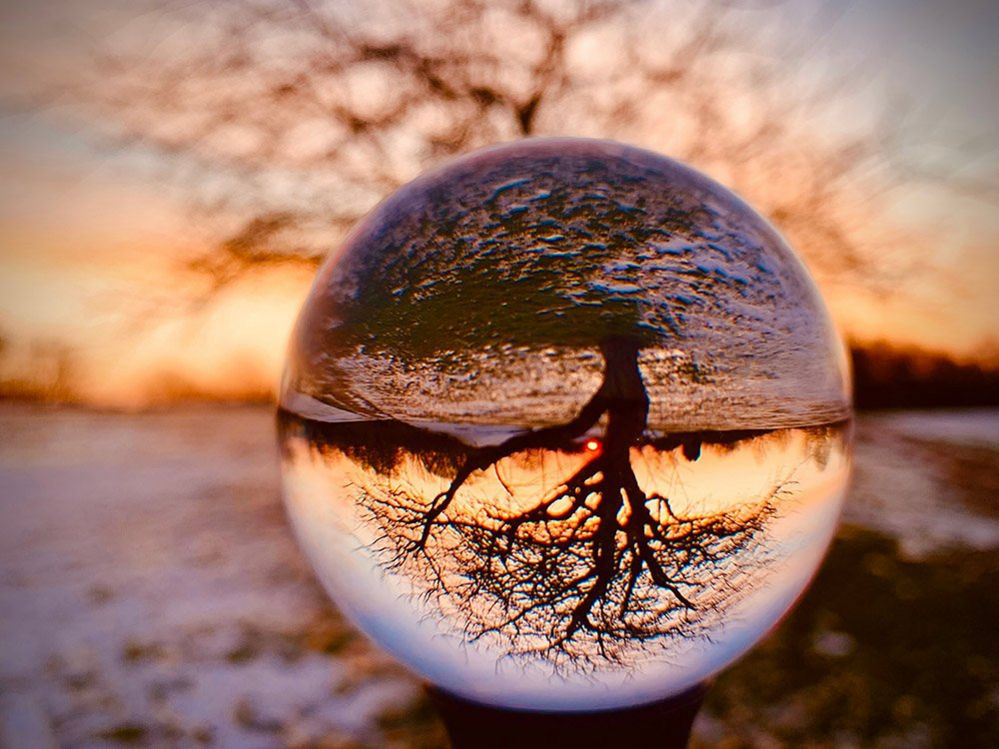

In [ ]:
from PIL import Image
from urllib import request

url = "https://ichef.bbci.co.uk/news/999/cpsprodpb/15951/production/_117310488_16.jpg"

with request.urlopen(url) as url_image:
    image = Image.open(url_image)

image.show()

In [ ]:
tensor = torch.randn(3, 500, 750)
tensor

tensor([[[ 0.0533,  0.6472, -0.7986,  ..., -0.1426,  1.1838, -0.5709],
         [ 0.9567,  1.4460, -0.3321,  ...,  0.8757,  1.0406, -0.4917],
         [ 0.1146, -0.4075,  0.1067,  ...,  0.8404, -1.2198, -0.5903],
         ...,
         [-0.0777, -2.5393, -0.1596,  ...,  0.1024, -1.3473, -1.6037],
         [-0.7578,  0.4319,  0.3949,  ..., -0.7340,  1.4363, -0.1914],
         [-0.6011, -1.1617, -0.8011,  ..., -1.4181,  0.2952, -0.1299]],

        [[ 0.3040,  0.2451,  1.2968,  ..., -0.4819,  0.3914,  0.5217],
         [-0.2665, -1.1848,  0.2403,  ...,  0.3766, -0.5939, -1.6842],
         [-0.3803,  1.6447,  0.1194,  ..., -1.0514,  0.2046, -0.0291],
         ...,
         [-0.5614, -0.7640,  1.2791,  ...,  0.6821, -2.3639, -0.1353],
         [ 0.4770, -1.1598, -1.1192,  ...,  0.5106, -0.2570,  0.3237],
         [-0.7134, -0.0330, -1.3018,  ..., -1.0016,  0.3788, -1.6922]],

        [[-1.2548, -0.5065,  1.2347,  ...,  0.5371,  0.8878,  1.7233],
         [-1.9761,  1.4940,  0.6421,  ..., -1

In [ ]:
t = torch.tensor(np.array(image), dtype=torch.float32)
t2 = t.permute(2, 0, 1)
t2.shape

torch.Size([3, 749, 999])

In [ ]:
con = nn.Conv2d(3, 32, kernel_size=2, stride=1, padding=1, bias=False)

In [ ]:
con(t2.reshape(1,3,749,999)).shape

torch.Size([1, 32, 750, 1000])